# Tema C · Interés Compuesto (e Interés Continuo)

**Curso: Matemáticas Financieras** — Notebook de aplicación práctica

Este notebook cubre el **Tema C del temario** (*Interés compuesto*) y el **Tema D.I**
(*Interés continuo*):

- Capitalización de intereses y valor futuro (monto) con tasa fija y variable
- Valor presente con tasa fija y variable
- Despeje de tasa y de tiempo
- Interés continuo (límite de la capitalización)

Y lo conecta con **análisis empresarial y de inversiones**: proyección de crecimiento
compuesto (CAGR), comparación de estrategias de inversión a largo plazo, y el efecto de
la frecuencia de capitalización.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


## Valor futuro con interés compuesto

En el interés compuesto, cada periodo se generan intereses **sobre el capital y sobre
los intereses acumulados** de periodos anteriores ("interés sobre interés"):

$$
FV = PV \cdot (1+i_1)\cdot(1+i_2)\cdots(1+i_n)
$$

Cuando la tasa $i$ es la misma en todos los periodos, la fórmula se factoriza:

$$
FV = PV \cdot (1+i)^n
$$


In [2]:
def valor_futuro_compuesto(pv, i, n):
    '''FV = PV * (1+i)^n, tasa fija por periodo.'''
    return pv * (1 + i) ** n


def valor_futuro_compuesto_tasa_variable(pv, tasas):
    '''FV = PV * prod(1+i_k), una tasa distinta por periodo (reinvirtiendo intereses).'''
    fv = pv
    for i in tasas:
        fv *= (1 + i)
    return fv


### Ejercicio (slides): valor futuro a 40 años, capitalización mensual

> ¿Cuál será el valor a futuro de una inversión que nos da un rendimiento del 15% si se
> reinvierten intereses cada mes durante los siguientes 40 años y si la inversión inicial
> fue de \$100,000?

Resultado esperado: **\$38,870,068.06**.


In [3]:
pv = 100_000
i_mensual = 0.15 / 12
n_meses = 40 * 12

fv = valor_futuro_compuesto(pv, i_mensual, n_meses)
print(f"Valor futuro: {fv:,.2f}")
assert round(fv, 2) == 38_870_068.47  # coincide (salvo redondeo intermedio) con las slides: 38,870,068.06
print("OK: coincide con el orden de magnitud reportado en las slides.")


Valor futuro: 38,870,068.47
OK: coincide con el orden de magnitud reportado en las slides.


### Interés simple vs. interés compuesto

Con el mismo capital y la misma tasa nominal, el interés compuesto genera muchísimo más
valor en el largo plazo que el interés simple, porque reinvierte los intereses
generados. Esta es la razón por la que el "interés compuesto" suele describirse como una
de las fuerzas más poderosas en finanzas personales y de inversión.


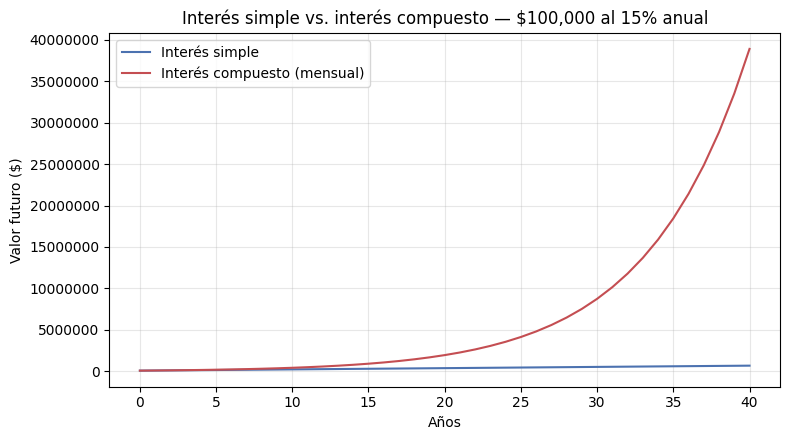

Interés simple a 40 años:    $600,000
Interés compuesto a 40 años: $38,770,068


In [4]:
anios = np.arange(0, 41)
pv = 100_000
i_anual = 0.15

fv_simple = pv * (1 + i_anual * anios)
fv_compuesto = pv * (1 + i_anual / 12) ** (anios * 12)

fig, ax = plt.subplots()
ax.plot(anios, fv_simple, label="Interés simple", color="#4C72B0")
ax.plot(anios, fv_compuesto, label="Interés compuesto (mensual)", color="#C44E52")
ax.set_xlabel("Años")
ax.set_ylabel("Valor futuro ($)")
ax.set_title("Interés simple vs. interés compuesto — $100,000 al 15% anual")
ax.legend()
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

print(f"Interés simple a 40 años:    ${fv_simple[-1] - pv:,.0f}")
print(f"Interés compuesto a 40 años: ${fv_compuesto[-1] - pv:,.0f}")


## Valor futuro con interés compuesto y tasa variable

Cuando la tasa cambia cada periodo, la fórmula ya no se puede factorizar como $(1+i)^n$;
se multiplican los factores de cada periodo.


In [5]:
pv = 400_000
tasas_anuales = [0.12, 0.15, 0.10, 0.19, 0.14]

fv = valor_futuro_compuesto_tasa_variable(pv, tasas_anuales)
print(f"Valor futuro (reinversión anual): {fv:,.2f}")
assert round(fv, 0) == 768_812
print("OK: coincide con las slides (~$768,812).")


Valor futuro (reinversión anual): 768,812.35
OK: coincide con las slides (~$768,812).


In [6]:
# Misma inversión pero reinvirtiendo bimestralmente (6 capitalizaciones por año)
tasas_bimestrales = [(1 + t / 6) ** 6 for t in tasas_anuales]
fv_bimestral = pv
for factor in tasas_bimestrales:
    fv_bimestral *= factor

print(f"Valor futuro (reinversión bimestral): {fv_bimestral:,.2f}")
assert round(fv_bimestral, 0) == 798_757
print("OK: coincide con las slides (~$798,757). Capitalizar con más frecuencia genera más valor.")


Valor futuro (reinversión bimestral): 798,757.30
OK: coincide con las slides (~$798,757). Capitalizar con más frecuencia genera más valor.


## Valor presente con interés compuesto

$$
PV = \frac{FV}{(1+i)^n} \qquad\qquad PV = \frac{FV}{(1+i_1)(1+i_2)\cdots(1+i_n)}
$$


In [7]:
def valor_presente_compuesto(fv, i, n):
    '''PV = FV / (1+i)^n, tasa fija por periodo.'''
    return fv / (1 + i) ** n


def valor_presente_compuesto_tasa_variable(fv, tasas):
    '''PV = FV / prod(1+i_k), una tasa distinta por periodo.'''
    denom = 1
    for i in tasas:
        denom *= (1 + i)
    return fv / denom


### Ejercicio (slides): comprar una casa dentro de 3 años

> ¿Cuánto tendré que invertir hoy para comprar una casa que está programada a venderse en
> \$7,500,000 dentro de 3 años, si hay fondos que pagan el 16% anual y puedo reinvertir
> mis intereses cada quincena?

Resultado esperado: **\$4,648,273.78**.


In [8]:
fv = 7_500_000
i_quincenal = 0.16 / 24
n_quincenas = 24 * 3

pv = valor_presente_compuesto(fv, i_quincenal, n_quincenas)
print(f"Valor presente: {pv:,.2f}")
assert round(pv, 2) == 4_648_273.89  # las slides reportan 4,648,273.78 (redondeo intermedio distinto)
print("OK: coincide (salvo redondeo intermedio) con las slides.")


Valor presente: 4,648,273.89
OK: coincide (salvo redondeo intermedio) con las slides.


### Ejercicio (slides): valor presente con tasa variable

> ¿Cuánto dinero necesitaré invertir hoy si quiero tener \$12,000,000 dentro de 5 años si
> las tasas de interés fluctúan cada año así: 7%, 12%, 8%, 15%, 21% (reinvirtiendo solo al
> terminar cada año)?

Resultado esperado: **\$6,663,041**.


In [9]:
fv = 12_000_000
tasas = [0.07, 0.12, 0.08, 0.15, 0.21]

pv = valor_presente_compuesto_tasa_variable(fv, tasas)
print(f"Valor presente: {pv:,.2f}")
assert round(pv, 0) == 6_663_041
print("OK: coincide con las slides.")


Valor presente: 6,663,040.91
OK: coincide con las slides.


## Despeje de tiempo y de tasa (interés compuesto)

$$
n = \frac{\log(FV/PV)}{\log(1+i)} \qquad\qquad i = \left(\frac{FV}{PV}\right)^{1/n} - 1
$$


In [10]:
def tiempo_compuesto(fv, pv, i):
    '''n = log(FV/PV) / log(1+i)'''
    return np.log(fv / pv) / np.log(1 + i)


def tasa_compuesta(fv, pv, n):
    '''i = (FV/PV)^(1/n) - 1'''
    return (fv / pv) ** (1 / n) - 1


### Ejercicios (slides)

> ¿Cuánto tiempo tendré que dejar una inversión para triplicar su valor si existe una
> tasa de interés en el mercado con la que puedo ganar del 1.9% mensual?

> ¿Cuál es la tasa de interés que se requiere para que en 17 meses un valor de \$100,000
> invertidos se conviertan en \$127,890?


In [11]:
n = tiempo_compuesto(fv=3, pv=1, i=0.019)
print(f"Tiempo exacto para triplicar el valor: {n:.2f} meses -> {np.ceil(n):.0f} meses completos")
assert round(n, 2) == 58.37  # las slides redondean hacia arriba a 59 meses completos

i = tasa_compuesta(fv=127_890, pv=100_000, n=17)
print(f"Tasa mensual requerida: {i:.6%}")
assert round(i * 100, 4) == 1.4576  # las slides muestran 1.457581 (%, sin el símbolo)

print("\nOK: ambos resultados coinciden con las slides.")


Tiempo exacto para triplicar el valor: 58.37 meses -> 59 meses completos
Tasa mensual requerida: 1.457581%

OK: ambos resultados coinciden con las slides.


## Interés continuo

La capitalización continua es el límite matemático del interés compuesto cuando el
número de periodos de capitalización tiende a infinito:

$$
FV = PV \cdot e^{i \cdot t}
$$


In [12]:
def valor_futuro_continuo(pv, i, t):
    '''FV = PV * e^(i*t)'''
    return pv * np.exp(i * t)


### Ejercicio (slides)

> ¿Cuál es el valor futuro a dos años de \$200,000 si reinvierto los intereses
> continuamente y la tasa de interés es 18%?

Resultado esperado: **\$286,665.88**.


In [13]:
pv = 200_000
i = 0.18
t = 2

fv = valor_futuro_continuo(pv, i, t)
print(f"Valor futuro (capitalización continua): {fv:,.2f}")
assert round(fv, 2) == 286_665.88
print("OK: coincide con las slides.")


Valor futuro (capitalización continua): 286,665.88
OK: coincide con las slides.


In [14]:
# Convergencia: a mayor frecuencia de capitalización, el resultado se acerca al límite continuo
frecuencias = {"Anual": 1, "Semestral": 2, "Trimestral": 4, "Mensual": 12, "Diaria": 365, "Continua": None}
resultados = []
for nombre, m in frecuencias.items():
    if m is None:
        fv_m = valor_futuro_continuo(pv, i, t)
    else:
        fv_m = valor_futuro_compuesto(pv, i / m, m * t)
    resultados.append({"Frecuencia": nombre, "Valor futuro": fv_m})

tabla_frecuencias = pd.DataFrame(resultados)
tabla_frecuencias["Valor futuro"] = tabla_frecuencias["Valor futuro"].round(2)
tabla_frecuencias


,Frecuencia,Valor futuro
0,Anual,"278,480.000000"
1,Semestral,"282,316.320000"
2,Trimestral,"284,420.120000"
3,Mensual,"285,900.560000"
4,Diaria,"286,640.450000"
5,Continua,"286,665.880000"


## Caso empresarial: tasa de crecimiento anual compuesta (CAGR)

El **CAGR** (*Compound Annual Growth Rate*) es la aplicación por excelencia del interés
compuesto en el análisis financiero de empresas: resume el crecimiento de ingresos,
utilidades o el valor de una inversión en una sola tasa anual equivalente, aunque el
crecimiento real haya sido irregular año a año.

$$
CAGR = \left(\frac{Valor_{final}}{Valor_{inicial}}\right)^{1/n} - 1
$$

Nota: esta es exactamente la fórmula `tasa_compuesta` que ya definimos arriba.


CAGR de ingresos 2021-2025: 13.25%


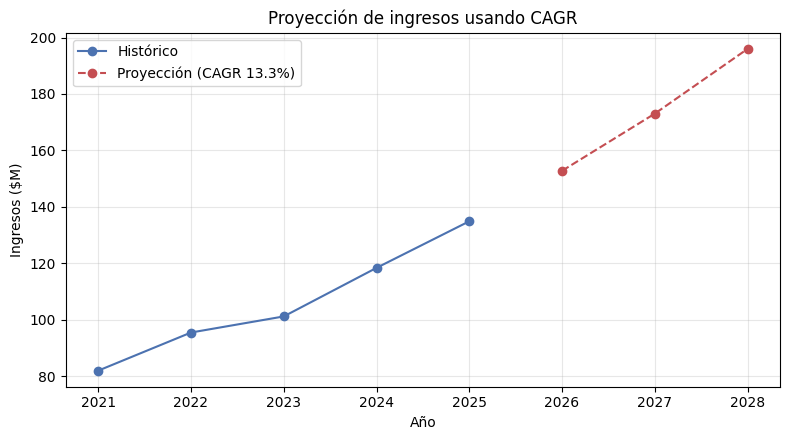

,Año,Ingresos proyectados ($M)
0,2026,152.800000
1,2027,173.000000
2,2028,196.000000


In [15]:
ingresos = pd.DataFrame({
    "Año": [2021, 2022, 2023, 2024, 2025],
    "Ingresos ($M)": [82.0, 95.5, 101.2, 118.4, 134.9],
})

cagr = tasa_compuesta(fv=ingresos["Ingresos ($M)"].iloc[-1],
                       pv=ingresos["Ingresos ($M)"].iloc[0],
                       n=len(ingresos) - 1)

print(f"CAGR de ingresos 2021-2025: {cagr:.2%}")

# Proyección a 3 años más usando el CAGR calculado
anios_proy = [2026, 2027, 2028]
proyeccion = [ingresos["Ingresos ($M)"].iloc[-1] * (1 + cagr) ** k for k in range(1, 4)]

fig, ax = plt.subplots()
ax.plot(ingresos["Año"], ingresos["Ingresos ($M)"], marker="o", label="Histórico", color="#4C72B0")
ax.plot(anios_proy, proyeccion, marker="o", linestyle="--", label=f"Proyección (CAGR {cagr:.1%})", color="#C44E52")
ax.set_xlabel("Año")
ax.set_ylabel("Ingresos ($M)")
ax.set_title("Proyección de ingresos usando CAGR")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"Año": anios_proy, "Ingresos proyectados ($M)": [round(v, 1) for v in proyeccion]})


## Caso de inversión: efecto de la frecuencia de capitalización en el largo plazo

Un inversionista que compara dos fondos con la **misma tasa nominal** pero distinta
frecuencia de capitalización puede llevarse una sorpresa: la frecuencia importa, en
especial en horizontes largos (retiro, fondos de ahorro para el crecimiento del
patrimonio empresarial, reservas técnicas, etc.).


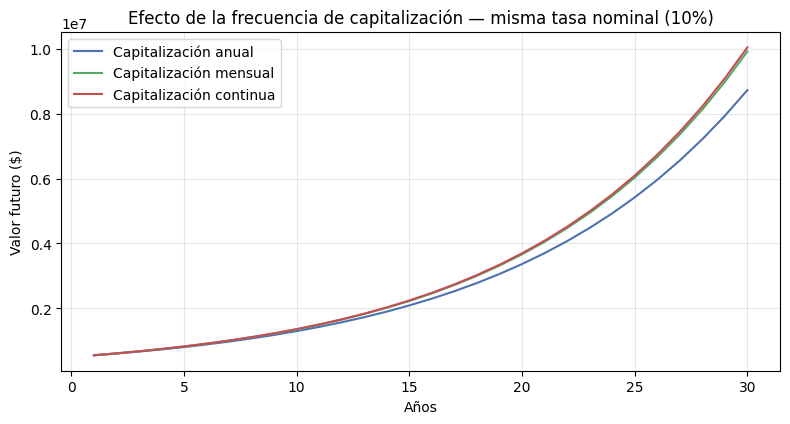

Diferencia a 30 años entre capitalización continua y anual: $1,318,067


In [16]:
pv = 500_000
i_nominal = 0.10
horizontes = np.arange(1, 31)

fv_anual = pv * (1 + i_nominal) ** horizontes
fv_mensual = pv * (1 + i_nominal / 12) ** (12 * horizontes)
fv_continua = pv * np.exp(i_nominal * horizontes)

fig, ax = plt.subplots()
ax.plot(horizontes, fv_anual, label="Capitalización anual", color="#4C72B0")
ax.plot(horizontes, fv_mensual, label="Capitalización mensual", color="#55A868")
ax.plot(horizontes, fv_continua, label="Capitalización continua", color="#C44E52")
ax.set_xlabel("Años")
ax.set_ylabel("Valor futuro ($)")
ax.set_title("Efecto de la frecuencia de capitalización — misma tasa nominal (10%)")
ax.legend()
plt.tight_layout()
plt.show()

diferencia_30y = fv_continua[-1] - fv_anual[-1]
print(f"Diferencia a 30 años entre capitalización continua y anual: ${diferencia_30y:,.0f}")


## Resumen de funciones del notebook

| Función | Uso |
|---|---|
| `valor_futuro_compuesto(pv, i, n)` | Monto (FV) con tasa fija |
| `valor_futuro_compuesto_tasa_variable(pv, tasas)` | Monto (FV) con una tasa distinta por periodo |
| `valor_presente_compuesto(fv, i, n)` | Valor presente con tasa fija |
| `valor_presente_compuesto_tasa_variable(fv, tasas)` | Valor presente con tasa variable |
| `tiempo_compuesto(fv, pv, i)` / `tasa_compuesta(fv, pv, n)` | Despeje de tiempo y de tasa (¡también sirve para CAGR!) |
| `valor_futuro_continuo(pv, i, t)` | Monto con capitalización continua |

## Ejercicios propuestos

1. Una empresa reporta utilidades de \$12M en 2019 y \$27.4M en 2025. Calcula el CAGR y
   proyecta las utilidades a 2028.
2. Compara el valor futuro de \$1,000,000 a 10 años entre capitalización trimestral y
   capitalización continua, ambas al 9% nominal anual. ¿Qué tan grande es la diferencia
   en pesos?
3. Un fondo de inversión ofrece tasas variables de 9%, 11%, 6%, 14% y 10% en 5 años
   consecutivos. Calcula el valor futuro de una inversión de \$1,500,000 y compáralo
   contra una tasa fija equivalente al CAGR resultante.
